# Popularidad

El objetivo de esta sección es analizar la popularidad tanto de las canciones como de los artistas presentes en el dataset

Las principales preguntas que se buscan responder son:

* ¿La popularidad de una canción está relacionada con su nivel de danceability?
* ¿Las canciones más energéticas tienden a ser más populares?
* ¿Existe una combinación de características que favorezca una mayor popularidad?
* ¿La duración de una canción influye en su popularidad?
* ¿La popularidad depende más del artista o de las características musicales?
* ¿Qué factores musicales influyen más en la popularidad de una canción?

<hr>

In [236]:
import pandas as pd
import ast

datos = pd.read_csv('../dataset/main_dataset.csv')
datos['artists_names'] = datos['artists_names'].apply(ast.literal_eval)
datos['artists_uris'] = datos['artists_uris'].apply(ast.literal_eval)
datos['artists_popularities'] = datos['artists_popularities'].apply(ast.literal_eval)
datos['artists_genres'] = datos['artists_genres'].apply(ast.literal_eval)
datos['artists_followers'] = datos['artists_followers'].apply(ast.literal_eval)

datos.info()
datos.head()

<class 'pandas.DataFrame'>
RangeIndex: 277938 entries, 0 to 277937
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   track_uri             277938 non-null  str    
 1   name                  277922 non-null  str    
 2   artists_names         277938 non-null  object 
 3   popularity            277938 non-null  int64  
 4   album_type            277938 non-null  str    
 5   is_playable           277938 non-null  bool   
 6   release_date          277938 non-null  str    
 7   artists_uris          277938 non-null  object 
 8   playlist_uris         277938 non-null  str    
 9   danceability          277938 non-null  float64
 10  energy                277938 non-null  float64
 11  key                   277938 non-null  float64
 12  loudness              277938 non-null  float64
 13  mode                  277938 non-null  float64
 14  speechiness           277938 non-null  float64
 15  acousticnes

,track_uri,name,artists_names,popularity,album_type,is_playable,release_date,artists_uris,playlist_uris,danceability,...,instrumentalness,liveness,valence,tempo,analysis_url,duration_ms,time_signature,artists_popularities,artists_genres,artists_followers
0,spotify:track:3v6sBj3swihU8pXQQHhDZo,Way Up (feat. Ava Re),[Floduxe],0,single,True,2015-11-20,[spotify:artist:4B7SI5PsnEgeMQd6gSIrbn],['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.611,...,0.000794,0.7530,0.520,128.050,https://api.spotify.com/v1/audio-analysis/3v6s...,195000.0,4.0,[9],[[]],[765]
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,"[Alina Baraz, Galimatias]",33,album,True,2015-09-04,"[spotify:artist:6hfwwpXqZPRC9CsKI7qtv1, spotif...",['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,"[68, 56]","[[etherpop, pop, r&b], [chillstep, future bass]]","[1283665, 138396]"
2,spotify:track:2CY92qejUrhyPUASawNVRr,Try Me,[DeJ Loaf],52,single,True,2014-10-15,[spotify:artist:7kFfY4UjNdNyaeUgLIEbIF],['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.560,...,0.000008,0.2410,0.247,170.044,https://api.spotify.com/v1/audio-analysis/2CY9...,217573.0,4.0,[65],"[[detroit hip hop, pop r&b, r&b, trap, trap qu...",[1544981]
3,spotify:track:11BPfwVbB7vok7KfjBeW4k,Walk on by (Sound Remedy Remix),[Noosa],0,single,True,2014-07-10,[spotify:artist:2F8tffsSfw1767WgjtAHBW],['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.525,...,0.000088,0.0888,0.199,92.011,https://api.spotify.com/v1/audio-analysis/11BP...,443478.0,4.0,[32],"[[shimmer pop, shiver pop]]",[18241]
4,spotify:track:3yUJKPsjvThlcQWTS9ttYx,Pretty Wings,"[Zak Waters, Pretty Sister]",0,single,True,2014-06-17,"[spotify:artist:0B8XBGloduGCBtRK8nm2YF, spotif...",['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.367,...,0.000001,0.0965,0.163,115.917,https://api.spotify.com/v1/audio-analysis/3yUJ...,225862.0,4.0,"[30, 39]","[[indie poptimism], [la pop]]","[10105, 13775]"


## Distribución de popularidad

In [237]:
print(datos['popularity'].skew())
datos['popularity'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

0.20146377786791098


count    277938.000000
mean         27.796631
std          20.866179
min           0.000000
25%           8.000000
50%          28.000000
75%          44.000000
90%          56.000000
95%          62.000000
99%          73.000000
max         100.000000
Name: popularity, dtype: float64

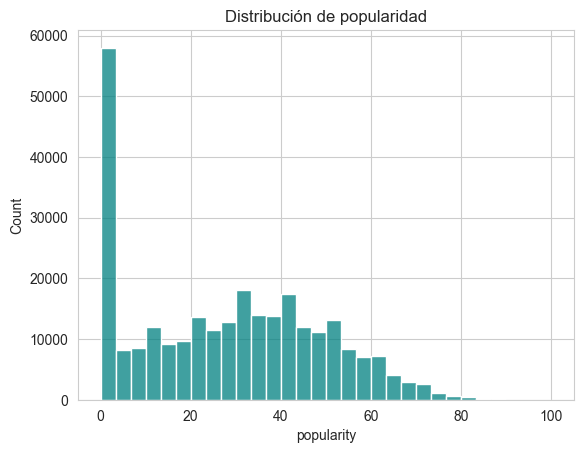

46868
25.857565356302487


In [238]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

sns.histplot(
    datos['popularity'],
    bins=30,
    color='teal',
)

plt.title(
'Distribución de popularidad'
)

plt.show()

print((datos['popularity'] == 0).sum())
print((datos['popularity'] <= 8).mean() * 100)

In [239]:
mas_populares = (datos.sort_values('popularity',ascending=False).head(25))

mas_populares[['name', 'artists_names', 'popularity', 'artists_popularities', 'artists_followers', 'artists_genres']]

,name,artists_names,popularity,artists_popularities,artists_followers,artists_genres
261193,Flowers,[Miley Cyrus],100,[92],[20250106],[[pop]]
274024,Boy's a liar Pt. 2,"[PinkPantheress, Ice Spice]",96,"[84, 84]","[1928246, 969451]","[[], []]"
138524,TQG,[KAROL G],96,[93],[33856064],"[[reggaeton, reggaeton colombiano, urbano lati..."
226293,"Shakira: Bzrp Music Sessions, Vol. 53","[Bizarrap, Shakira]",96,"[88, 92]","[10050089, 28191070]","[[argentine hip hop, pop venezolano, trap arge..."
269682,Die For You - Remix,"[The Weeknd, Ariana Grande]",95,"[98, 91]","[62165751, 89209352]","[[canadian contemporary r&b, canadian pop, pop..."
260639,Calm Down (with Selena Gomez),"[Rema, Selena Gomez]",94,"[82, 87]","[2104953, 41326077]","[[nigerian pop], [dance pop, pop, post-teen pop]]"
266216,I'm Good (Blue),"[David Guetta, Bebe Rexha]",94,"[89, 83]","[25778023, 8095948]","[[big room, dance pop, edm, pop, pop dance], [..."
193140,La Bachata,[Manuel Turizo],93,[85],[11848110],"[[colombian pop, latin pop, reggaeton, reggaet..."
269098,Here With Me,[d4vd],93,[82],[909208],[[bedroom pop]]
109517,Anti-Hero,[Taylor Swift],93,[100],[71194980],[[pop]]


Visualmente, el histograma mostró un pico importante en valores cercanos a 0, indicando que existe una gran cantidad de canciones con niveles muy bajos de popularidad.

Sin embargo, después de este pico inicial la distribución se vuelve más dispersa y concentra la mayor parte de observaciones aproximadamente entre valores de 20 y 40, lo que sugiere que una proporción importante de canciones alcanza niveles intermedios de exposición.

Los percentiles permiten observar mejor este comportamiento:

- El 25% de las canciones tiene popularidad igual o menor a 8.
- El 50% tiene popularidad menor o igual a 28.
- El 75% permanece por debajo de 44.
- Incluso el 90% de las canciones no supera una popularidad de 56.

Esto indica que las canciones altamente populares representan una fracción relativamente pequeña del conjunto.

Aunque visualmente el pico en valores bajos podría sugerir una fuerte asimetría, el valor de skewness ≈ 0.2 indica que la distribución mantiene una asimetría positiva baja, por lo que no puede considerarse extremadamente sesgada.

En conjunto, los resultados sugieren que la mayoría de canciones alcanza niveles bajos o intermedios de popularidad, mientras que las canciones extremadamente populares constituyen casos menos frecuentes dentro del catálogo.

## Relación entre características musicales y popularidad

In [240]:
metricas = [
'danceability',
'energy',
'valence',
'tempo',
'acousticness',
'speechiness',
'instrumentalness',
'liveness',
'duration_ms'
]

In [241]:
corr_p = datos[metricas+['popularity']].corr(method='pearson')
corr_p['popularity']

danceability        0.110521
energy              0.053145
valence             0.025027
tempo               0.007020
acousticness       -0.085015
speechiness        -0.012517
instrumentalness   -0.142096
liveness           -0.040241
duration_ms        -0.098794
popularity          1.000000
Name: popularity, dtype: float64

In [242]:
corr_s = datos[metricas+['popularity']].corr(method='spearman')
corr_s['popularity']

danceability        0.104278
energy              0.039465
valence             0.022563
tempo               0.005686
acousticness       -0.051921
speechiness         0.014691
instrumentalness   -0.151547
liveness           -0.020918
duration_ms        -0.082911
popularity          1.000000
Name: popularity, dtype: float64

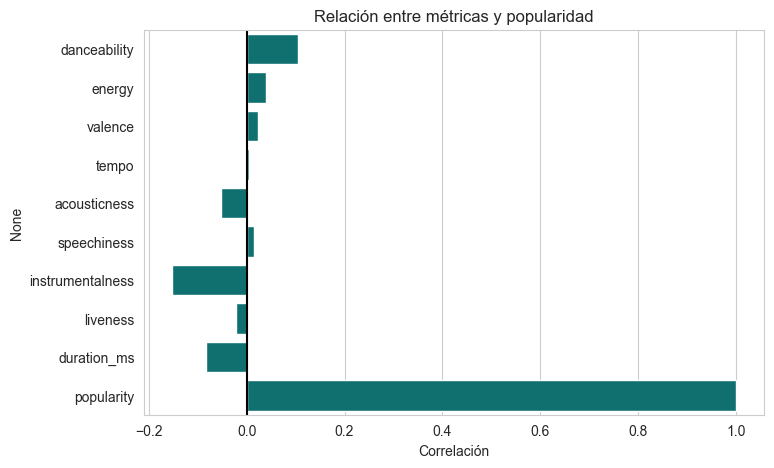

In [243]:
plt.figure(
    figsize=(8,5)
)

sns.barplot(
    x=corr_s['popularity'],
    y=corr_s.index,
    color='teal'
)

plt.axvline(
    0,
    color='black'
)

plt.xlabel(
    'Correlación'
)

plt.title(
'Relación entre métricas y popularidad'
)


plt.show()

Las relaciones observadas fueron:

| Variable | Pearson | Spearman |
|---|---:|---:|
| Danceability | 0.111 | 0.104 |
| Energy | 0.053 | 0.039 |
| Valence | 0.025 | 0.023 |
| Tempo | 0.007 | 0.006 |
| Acousticness | -0.085 | -0.052 |
| Speechiness | -0.013 | 0.015 |
| Instrumentalness | -0.142 | -0.152 |
| Liveness | -0.040 | -0.021 |
| Duration | -0.099 | -0.083 |

En general, todas las correlaciones permanecieron cercanas a cero, indicando asociaciones débiles tanto lineales como monotónicas.

La variable que mostró la relación más alta fue instrumentalness, con una correlación cercana a −0.15, sugiriendo que canciones con menor presencia instrumental tienden ligeramente a presentar mayor popularidad.

También se observó una relación negativa débil con la duración y con acousticness.

Sin embargo, debido a que ninguna variable alcanzó magnitudes elevadas, los resultados sugieren que la popularidad no parece depender fuertemente de una única característica musical de forma aislada.

## Popularidad de una canción en relación con los artistas

In [244]:
datos = datos.explode(['artists_names', 'artists_popularities', 'artists_genres', 'artists_followers'])

datos['artists_uris'] = (datos['artists_uris'].str[0])

datos.head()

,track_uri,name,artists_names,popularity,album_type,is_playable,release_date,artists_uris,playlist_uris,danceability,...,instrumentalness,liveness,valence,tempo,analysis_url,duration_ms,time_signature,artists_popularities,artists_genres,artists_followers
0,spotify:track:3v6sBj3swihU8pXQQHhDZo,Way Up (feat. Ava Re),Floduxe,0,single,True,2015-11-20,spotify:artist:4B7SI5PsnEgeMQd6gSIrbn,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.611,...,0.000794,0.7530,0.520,128.050,https://api.spotify.com/v1/audio-analysis/3v6s...,195000.0,4.0,9,[],765
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,Alina Baraz,33,album,True,2015-09-04,spotify:artist:6hfwwpXqZPRC9CsKI7qtv1,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,68,"[etherpop, pop, r&b]",1283665
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,Galimatias,33,album,True,2015-09-04,spotify:artist:6hfwwpXqZPRC9CsKI7qtv1,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,56,"[chillstep, future bass]",138396
2,spotify:track:2CY92qejUrhyPUASawNVRr,Try Me,DeJ Loaf,52,single,True,2014-10-15,spotify:artist:7kFfY4UjNdNyaeUgLIEbIF,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.560,...,0.000008,0.2410,0.247,170.044,https://api.spotify.com/v1/audio-analysis/2CY9...,217573.0,4.0,65,"[detroit hip hop, pop r&b, r&b, trap, trap queen]",1544981
3,spotify:track:11BPfwVbB7vok7KfjBeW4k,Walk on by (Sound Remedy Remix),Noosa,0,single,True,2014-07-10,spotify:artist:2F8tffsSfw1767WgjtAHBW,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.525,...,0.000088,0.0888,0.199,92.011,https://api.spotify.com/v1/audio-analysis/11BP...,443478.0,4.0,32,"[shimmer pop, shiver pop]",18241


In [245]:
variables = [
'artists_popularities',
'artists_followers',
'popularity'
]

corr_s = datos[variables].corr(method='spearman')
corr_s['popularity']

artists_popularities    0.457529
artists_followers       0.272441
popularity              1.000000
Name: popularity, dtype: float64

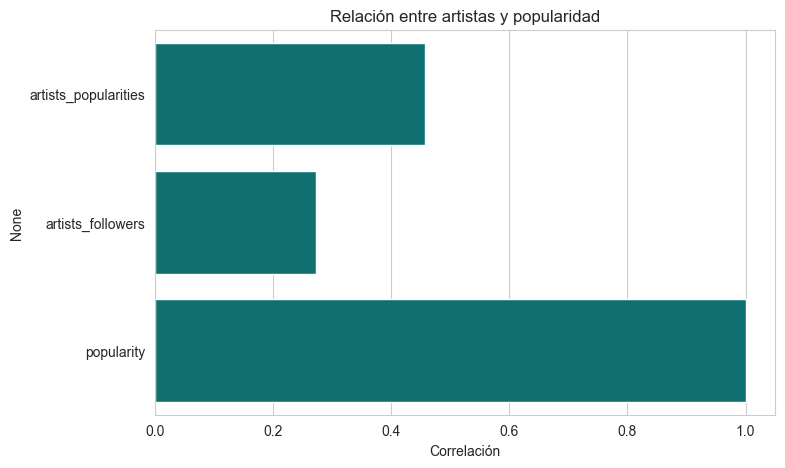

In [246]:
plt.figure(
    figsize=(8,5)
)

sns.barplot(
    x=corr_s['popularity'],
    y=corr_s.index,
    color='teal'
)

plt.xlabel(
    'Correlación'
)

plt.title(
'Relación entre artistas y popularidad'
)


plt.show()

Para evaluar si el éxito de una canción está más asociado al artista o a sus características musicales, se analizaron las correlaciones entre la popularidad de la canción y variables relacionadas con el artista.

Se calcularon correlaciones de Spearman obteniendo:

| Variable | Correlación |
|---|---:|
| Popularidad del artista | 0.458 |
| Seguidores del artista | 0.272 |

Al comparar estos resultados con las correlaciones obtenidas previamente para las métricas musicales (todas menores a ±0.15), se observa que las variables asociadas al artista presentan relaciones considerablemente más altas.

La popularidad del artista mostró una relación positiva de magnitud moderada con la popularidad de sus canciones, mientras que el número de seguidores presentó una relación positiva más débil pero aún superior a la observada para las características musicales individuales.

Estos resultados sugieren que el desempeño de una canción parece depender en mayor medida del alcance, relevancia o reconocimiento previo del artista que de una característica musical específica considerada de forma aislada.

Sin embargo, las correlaciones siguen siendo moderadas, por lo que la popularidad probablemente también está influenciada por otros factores.

In [247]:
datos.head()

,track_uri,name,artists_names,popularity,album_type,is_playable,release_date,artists_uris,playlist_uris,danceability,...,instrumentalness,liveness,valence,tempo,analysis_url,duration_ms,time_signature,artists_popularities,artists_genres,artists_followers
0,spotify:track:3v6sBj3swihU8pXQQHhDZo,Way Up (feat. Ava Re),Floduxe,0,single,True,2015-11-20,spotify:artist:4B7SI5PsnEgeMQd6gSIrbn,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.611,...,0.000794,0.7530,0.520,128.050,https://api.spotify.com/v1/audio-analysis/3v6s...,195000.0,4.0,9,[],765
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,Alina Baraz,33,album,True,2015-09-04,spotify:artist:6hfwwpXqZPRC9CsKI7qtv1,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,68,"[etherpop, pop, r&b]",1283665
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,Galimatias,33,album,True,2015-09-04,spotify:artist:6hfwwpXqZPRC9CsKI7qtv1,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,56,"[chillstep, future bass]",138396
2,spotify:track:2CY92qejUrhyPUASawNVRr,Try Me,DeJ Loaf,52,single,True,2014-10-15,spotify:artist:7kFfY4UjNdNyaeUgLIEbIF,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.560,...,0.000008,0.2410,0.247,170.044,https://api.spotify.com/v1/audio-analysis/2CY9...,217573.0,4.0,65,"[detroit hip hop, pop r&b, r&b, trap, trap queen]",1544981
3,spotify:track:11BPfwVbB7vok7KfjBeW4k,Walk on by (Sound Remedy Remix),Noosa,0,single,True,2014-07-10,spotify:artist:2F8tffsSfw1767WgjtAHBW,['spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM'],0.525,...,0.000088,0.0888,0.199,92.011,https://api.spotify.com/v1/audio-analysis/11BP...,443478.0,4.0,32,"[shimmer pop, shiver pop]",18241


In [248]:
datos = pd.read_csv('../dataset/main_dataset.csv')
datos['playlist_uris'] = datos['playlist_uris'].apply(ast.literal_eval)

datos.info()
datos.head()

<class 'pandas.DataFrame'>
RangeIndex: 277938 entries, 0 to 277937
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   track_uri             277938 non-null  str    
 1   name                  277922 non-null  str    
 2   artists_names         277938 non-null  str    
 3   popularity            277938 non-null  int64  
 4   album_type            277938 non-null  str    
 5   is_playable           277938 non-null  bool   
 6   release_date          277938 non-null  str    
 7   artists_uris          277938 non-null  str    
 8   playlist_uris         277938 non-null  object 
 9   danceability          277938 non-null  float64
 10  energy                277938 non-null  float64
 11  key                   277938 non-null  float64
 12  loudness              277938 non-null  float64
 13  mode                  277938 non-null  float64
 14  speechiness           277938 non-null  float64
 15  acousticnes

,track_uri,name,artists_names,popularity,album_type,is_playable,release_date,artists_uris,playlist_uris,danceability,...,instrumentalness,liveness,valence,tempo,analysis_url,duration_ms,time_signature,artists_popularities,artists_genres,artists_followers
0,spotify:track:3v6sBj3swihU8pXQQHhDZo,Way Up (feat. Ava Re),['Floduxe'],0,single,True,2015-11-20,['spotify:artist:4B7SI5PsnEgeMQd6gSIrbn'],[spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM],0.611,...,0.000794,0.7530,0.520,128.050,https://api.spotify.com/v1/audio-analysis/3v6s...,195000.0,4.0,[9],[[]],[765]
1,spotify:track:7KCWmFdw0TzoJbKtqRRzJO,Fantasy - Felix Jaehn Remix,"['Alina Baraz', 'Galimatias']",33,album,True,2015-09-04,"['spotify:artist:6hfwwpXqZPRC9CsKI7qtv1', 'spo...",[spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM],0.638,...,0.009530,0.3490,0.250,122.985,https://api.spotify.com/v1/audio-analysis/7KCW...,194641.0,4.0,"[68, 56]","[['etherpop', 'pop', 'r&b'], ['chillstep', 'fu...","[1283665, 138396]"
2,spotify:track:2CY92qejUrhyPUASawNVRr,Try Me,['DeJ Loaf'],52,single,True,2014-10-15,['spotify:artist:7kFfY4UjNdNyaeUgLIEbIF'],[spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM],0.560,...,0.000008,0.2410,0.247,170.044,https://api.spotify.com/v1/audio-analysis/2CY9...,217573.0,4.0,[65],"[['detroit hip hop', 'pop r&b', 'r&b', 'trap',...",[1544981]
3,spotify:track:11BPfwVbB7vok7KfjBeW4k,Walk on by (Sound Remedy Remix),['Noosa'],0,single,True,2014-07-10,['spotify:artist:2F8tffsSfw1767WgjtAHBW'],[spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM],0.525,...,0.000088,0.0888,0.199,92.011,https://api.spotify.com/v1/audio-analysis/11BP...,443478.0,4.0,[32],"[['shimmer pop', 'shiver pop']]",[18241]
4,spotify:track:3yUJKPsjvThlcQWTS9ttYx,Pretty Wings,"['Zak Waters', 'Pretty Sister']",0,single,True,2014-06-17,"['spotify:artist:0B8XBGloduGCBtRK8nm2YF', 'spo...",[spotify:playlist:5JJZvA3VR9RZ5XIr0reWiM],0.367,...,0.000001,0.0965,0.163,115.917,https://api.spotify.com/v1/audio-analysis/3yUJ...,225862.0,4.0,"[30, 39]","[['indie poptimism'], ['la pop']]","[10105, 13775]"


In [249]:
import numpy as np

P90 = datos['popularity'].quantile(.9)
P10 = datos['popularity'].quantile(.1)

datos['grupo_pop'] = np.select([datos['popularity'] <= P10, datos['popularity'] >= P90],['Baja','Alta'],default='Intermedia')

datos['grupo_pop'].value_counts()

grupo_pop
Intermedia    202253
Baja           46868
Alta           28817
Name: count, dtype: int64

### Construcción de perfiles extremos de popularidad

Para identificar diferencias musicales más claras, se compararon canciones de popularidad alta y baja.

Se definieron dos grupos:

- Canciones de baja popularidad: percentil 10 inferior.
- Canciones de alta popularidad: percentil 90 superior.

Las canciones intermedias se conservaron únicamente como referencia.

In [250]:
perfil = (datos.groupby('grupo_pop')[metricas].median())

perfil

,danceability,energy,valence,tempo,acousticness,speechiness,instrumentalness,liveness,duration_ms
grupo_pop,,,,,,,,,
Alta,0.632,0.654,0.496,120.146,0.169,0.0507,0.000006,0.122,206379.0
Baja,0.563,0.616,0.456,119.982,0.241,0.0478,0.001550,0.124,220684.5
Intermedia,0.563,0.573,0.418,119.734,0.292,0.0466,0.002660,0.120,212663.0


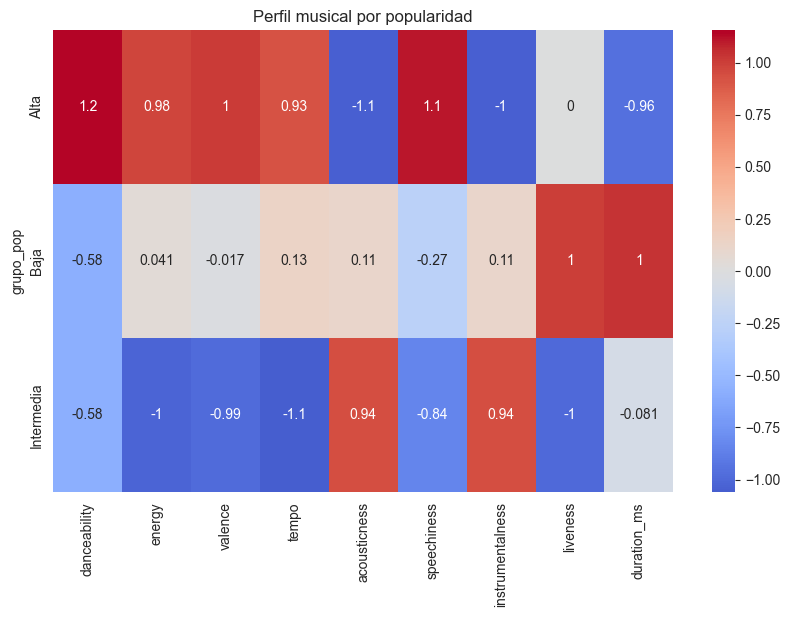

In [251]:
perfil_norm = (perfil-perfil.mean())/perfil.std()

plt.figure(
    figsize=(10,6)
)

sns.heatmap(
    perfil_norm,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title(
'Perfil musical por popularidad'
)

plt.show()

Se compararon las medianas de las características musicales entre canciones de alta y baja popularidad para identificar posibles perfiles asociados al éxito.

Se observaron algunas diferencias consistentes:

- Las canciones más populares tendieron a presentar mayor danceability.
- También mostraron niveles ligeramente mayores de energy y valence.
- Presentaron menor acousticness, indicando una menor presencia de elementos acústicos.
- La instrumentalness fue considerablemente menor, sugiriendo que las canciones populares suelen incluir contenido vocal.
- La duración promedio también fue ligeramente menor.

Por otro lado, variables como tempo y liveness mostraron cambios mínimos entre grupos.

Aunque existe un patrón reconocible, las diferencias observadas no fueron extremadamente grandes, lo que coincide con el análisis de correlaciones realizado previamente.

En conjunto, los resultados sugieren que las canciones exitosas sí presentan ciertas tendencias musicales comunes; sin embargo, estas características por sí solas parecen insuficientes para explicar completamente la popularidad.

In [252]:
from sklearn.preprocessing import MinMaxScaler

datos_norm = datos.copy()

scaler = MinMaxScaler()

datos_norm[metricas] = (
    scaler.fit_transform(
        datos_norm[metricas]
    )
)

diversidad = datos_norm[metricas].groupby(datos_norm['grupo_pop']).std()

diversidad['indice_diversidad'] = (diversidad.mean(axis=1))

diversidad

,danceability,energy,valence,tempo,acousticness,speechiness,instrumentalness,liveness,duration_ms,indice_diversidad
grupo_pop,,,,,,,,,,
Alta,0.171156,0.229987,0.247705,0.119950,0.302892,0.099851,0.239915,0.147728,0.016378,0.175063
Baja,0.186706,0.272448,0.270098,0.124650,0.362136,0.144159,0.364339,0.178702,0.030649,0.214876
Intermedia,0.193048,0.286039,0.268614,0.124868,0.372649,0.111425,0.385067,0.161960,0.031173,0.214983


0.18568952521830495


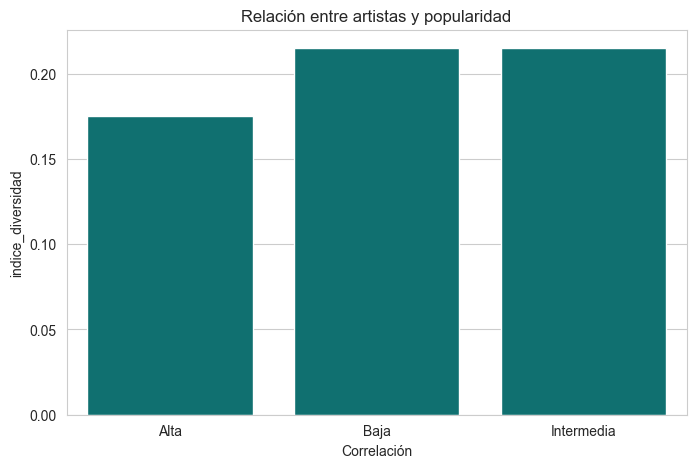

In [253]:
print((max(diversidad['indice_diversidad'])- min(diversidad['indice_diversidad']))/max(diversidad['indice_diversidad']))

plt.figure(
    figsize=(8,5)
)

sns.barplot(
    y=diversidad['indice_diversidad'],
    x=diversidad.index,
    color='teal'
)

plt.xlabel(
    'Correlación'
)

plt.title(
'Relación entre artistas y popularidad'
)


plt.show()

### ¿Las canciones populares presentan perfiles musicales más homogéneos?

Para evaluar si las canciones exitosas comparten perfiles musicales más similares entre sí, se construyó un índice global de diversidad.

Debido a que las variables musicales se encontraban en escalas distintas, primero se normalizaron mediante Min-Max Scaling y posteriormente se calculó la desviación estándar de cada métrica dentro de cada grupo de popularidad.

Finalmente, se construyó un índice de diversidad como el promedio de las desviaciones estándar obtenidas.

Los resultados fueron:

| Grupo | Índice de diversidad |
|---|---:|
| Alta | 0.175 |
| Intermedia | 0.217 |
| Baja | 0.217 |

Se observó que las canciones de alta popularidad presentan una menor variabilidad global en sus características musicales.

En comparación con canciones de baja popularidad, el grupo exitoso mostró aproximadamente 19% menos dispersión.

Este resultado sugiere que las canciones populares tienden a concentrarse ligeramente más alrededor de ciertos perfiles musicales comunes.

## Relación de popularidad con la cantidad de playlists

In [254]:
datos['n_playlists'] = (datos['playlist_uris'].apply(len))

datos['n_playlists'].describe(percentiles=[.5,.75,.9,.95,.99])

count    277938.000000
mean          1.653635
std           2.513363
min           1.000000
50%           1.000000
75%           1.000000
90%           3.000000
95%           4.000000
99%          12.000000
max          97.000000
Name: n_playlists, dtype: float64

<Axes: xlabel='n_playlists', ylabel='Count'>

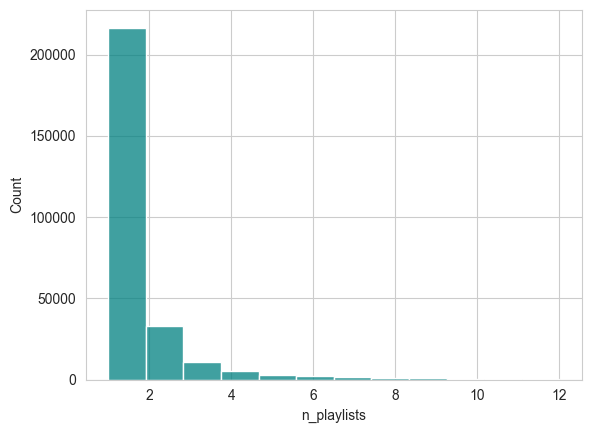

In [255]:
limite = datos['n_playlists'].quantile(0.99)

sns.histplot(data=datos,
            x=datos['n_playlists'][
                datos['n_playlists'] <= limite
                ],
            color='teal',
            bins=12)

### Distribución del número de playlists por canción


La distribución mostró una fuerte concentración en valores bajos.

La mediana y el percentil 75 indican que al menos el 75% de las canciones aparece únicamente en una playlist, mientras que incluso el 90% aparece en tres playlists o menos.

Visualmente, el histograma presentó una distribución fuertemente asimétrica hacia la derecha, con un pico muy pronunciado en el valor 1 y una caída rápida en frecuencias para valores mayores.

Esto sugiere que la mayoría de canciones recibe una exposición limitada dentro del conjunto analizado, mientras que solo una pequeña proporción logra aparecer repetidamente en distintas playlists.

La diferencia entre la media (1.65) y la mediana (1) también indica la presencia de un grupo reducido de canciones con niveles de exposición considerablemente mayores al resto.

In [256]:
datos[['n_playlists', 'popularity']].corr(method='spearman')

,n_playlists,popularity
n_playlists,1.00000,0.33427
popularity,0.33427,1.00000


<Axes: xlabel='n_playlists', ylabel='popularity'>

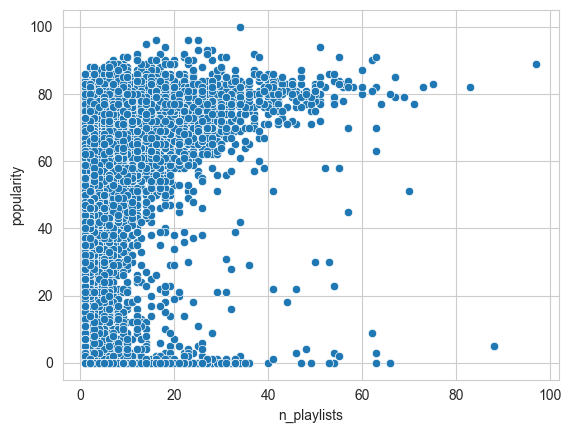

In [257]:
sns.scatterplot(
    data=datos,
    x='n_playlists',
    y='popularity'
)

Se exploró la relación entre el número de playlists en las que aparece una canción y su nivel de popularidad.

La correlación de Spearman obtenida fue:

- Número de playlists ↔ Popularidad: 0.334

Este resultado indica una relación positiva de intensidad baja a moderada.

Visualmente, el diagrama de dispersión no mostró una tendencia lineal clara; sin embargo, sí se observó que conforme aumenta el número de playlists disminuye la presencia de canciones con popularidad muy baja y aparecen con mayor frecuencia canciones de popularidad media y alta.

Al mismo tiempo, incluso para cantidades similares de playlists continúa existiendo una dispersión considerable en los niveles de popularidad.

Esto sugiere que aparecer en más playlists podría favorecer una mayor exposición y asociarse con canciones más populares, aunque por sí solo no parece suficiente para explicar completamente el éxito de una canción.

En comparación con las características musicales analizadas anteriormente, el número de playlists mostró una relación más alta con la popularidad, lo que refuerza la idea de que factores de distribución y alcance podrían tener mayor influencia que las propiedades del audio.

<Axes: xlabel='n_playlists', ylabel='popularity'>

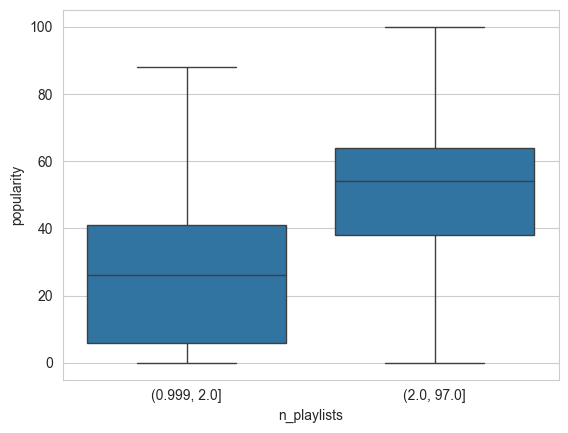

In [ ]:
sns.boxplot(
    data=datos,
    x=pd.qcut(
        datos['n_playlists'],
        5,
        duplicates='drop'
    ),
    y='popularity'
)

In [259]:
datos['artists_names'] = datos['artists_names'].apply(ast.literal_eval)
datos['artists_uris'] = datos['artists_uris'].apply(ast.literal_eval)
datos['artists_popularities'] = datos['artists_popularities'].apply(ast.literal_eval)
datos['artists_genres'] = datos['artists_genres'].apply(ast.literal_eval)
datos['artists_followers'] = datos['artists_followers'].apply(ast.literal_eval)

datos = datos.explode(['artists_names', 'artists_popularities', 'artists_genres', 'artists_followers'])

In [260]:
variables = [
'n_playlists',
'artists_popularities',
'artists_followers',
'popularity'
]

datos[
variables
].corr(
method='spearman'
)

,n_playlists,artists_popularities,artists_followers,popularity
n_playlists,1.000000,0.286273,0.260843,0.338807
artists_popularities,0.286273,1.000000,0.677955,0.457529
artists_followers,0.260843,0.677955,1.000000,0.272441
popularity,0.338807,0.457529,0.272441,1.000000


<hr>

## Resolución de preguntas

### ¿La popularidad de una canción está relacionada con su nivel de danceability?

Se encontró una relación positiva pero débil entre danceability y popularidad.

Las correlaciones obtenidas fueron:

- Pearson: 0.111
- Spearman: 0.104

Además, al comparar perfiles musicales entre canciones de alta y baja popularidad se observó que las canciones más populares presentaron una mediana de danceability mayor (0.641 vs 0.559).

Esto sugiere que canciones más bailables tienden ligeramente a presentar mayor popularidad, aunque el efecto observado es reducido.


### ¿Las canciones más energéticas tienden a ser más populares?

Se observó una relación positiva débil entre energy y popularidad.

Las correlaciones fueron:

- Pearson: 0.053
- Spearman: 0.039

Sin embargo, en el análisis por perfiles las canciones de alta popularidad mostraron niveles de energía ligeramente mayores (0.660 vs 0.601).

Por lo tanto, existe una tendencia positiva, aunque la energía por sí sola parece tener poca capacidad explicativa.

### ¿Existe una combinación de características que favorezca una mayor popularidad?

Sí se observaron diferencias entre perfiles musicales de canciones exitosas y no exitosas.

Las canciones de alta popularidad tendieron a presentar:

- Mayor danceability
- Mayor energy
- Mayor valence
- Menor acousticness
- Menor instrumentalness
- Menor duración

Además, el índice global de diversidad mostró menor variabilidad en canciones populares (0.175) respecto a canciones de baja popularidad (0.217).

Esto sugiere que las canciones exitosas tienden a concentrarse ligeramente alrededor de ciertos perfiles musicales comunes, aunque no se encontró evidencia suficiente para afirmar la existencia de una fórmula única de éxito.

### ¿La duración de una canción influye en su popularidad?

La duración presentó una relación negativa débil con la popularidad.

Correlaciones:

- Pearson: −0.099
- Spearman: −0.083

En el análisis de perfiles también se observó una duración mediana menor en canciones populares (203,920 ms) comparada con canciones poco populares (220,096 ms).

Los resultados sugieren que canciones ligeramente más cortas podrían asociarse con mayor popularidad, aunque el efecto observado es pequeño.


### ¿La popularidad depende más del artista o de las características musicales?

Sí.

Las variables relacionadas con el artista mostraron relaciones considerablemente mayores que las métricas musicales.

Correlaciones de Spearman:

- Popularidad del artista → 0.458
- Seguidores del artista → 0.272

Mientras que ninguna característica musical individual superó una magnitud de 0.15.

Esto sugiere que el alcance o relevancia del artista parece explicar mejor la popularidad de una canción que una característica musical aislada.

### ¿Qué factores musicales influyen más en la popularidad de una canción?

Entre las métricas analizadas, las asociaciones más altas fueron:

- Instrumentalness → −0.152
- Danceability → 0.104
- Duration → −0.083
- Acousticness → −0.052
- Energy → 0.039

Aunque estas fueron las relaciones más altas encontradas, todas permanecieron dentro de rangos bajos.

En conjunto, los resultados indican que ninguna característica musical individual parece tener una influencia dominante sobre la popularidad.